## 02 — Análise Exploratória: Coesão Partidária e Rebeldes
- Analisa as votações de Plenário de 2025: distribuições básicas,
- Coesão de cada partido e ranking dos deputados mais "rebeldes".


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROCESSED_DIR = '../data/processed/'

df_deputados = pd.read_parquet(f'{PROCESSED_DIR}deputados.parquet')
df_votacoes = pd.read_parquet(f'{PROCESSED_DIR}votacoes.parquet')
df_votos = pd.read_parquet(f'{PROCESSED_DIR}votos.parquet')
df_orientacoes = pd.read_parquet(f'{PROCESSED_DIR}orientacoes.parquet')

In [2]:
print(f"Quantidade de votações no plenário em 2025: {df_votacoes.shape[0]}")
print(f"Quantidade de deputados que votaram em 2025: {df_votos['deputado_id'].nunique()}")
print(f"Quantidade de votos em 2025: {df_votos.shape[0]}")
print(f"Data da primeira votação em 2025: {df_votacoes['data'].min()}")
print(f"Data da última votação em 2025: {df_votacoes['data'].max()}")


Quantidade de votações no plenário em 2025: 429
Quantidade de deputados que votaram em 2025: 551
Quantidade de votos em 2025: 171217
Data da primeira votação em 2025: 2025-02-11 00:00:00
Data da última votação em 2025: 2025-12-16 00:00:00


In [3]:
df_votos['voto'].value_counts()

voto
Sim          99870
Não          69794
Artigo 17      420
Obstrução      375
Abstenção      337
Name: count, dtype: int64

## 2. Distribuição dos tipos de voto

Os votos possíveis são: **Sim**, **Não**, **Abstenção**, **Obstrução** e **Artigo 17** (conflito de interesses).  
Sim e Não dominam (~99% dos registros). Os demais são raros, mas importantes para decidir a codificação no mapa ideológico:
- Sim/Não: votos com posição clara → serão codificados como +1/−1
- Abstenção/Obstrução: posição neutra/procedimental → codificados como 0
- Artigo 17: deputado impedido de votar → tratado como ausência (NaN)

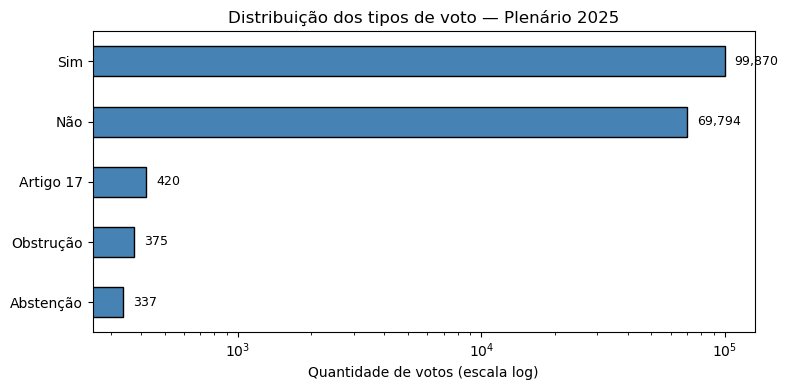

In [4]:
vote_counts = df_votos['voto'].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
vote_counts.plot.barh(ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Quantidade de votos (escala log)')
ax.set_ylabel('')
ax.set_title('Distribuição dos tipos de voto — Plenário 2025')
ax.set_xscale('log')
ax.invert_yaxis()

for i, v in enumerate(vote_counts):
    ax.text(v * 1.1, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 3. Participação dos deputados

Histograma de quantas votações cada deputado participou.  
A maioria dos deputados votou 300–400 vezes. Apenas 18 deputados têm menos de 50 votos — provavelmente suplentes que assumiram temporariamente.  
Threshold de 50 votos é seguro para filtrar: mantém 533 dos 551 deputados.

Mediana: 338 votos
Média: 311 votos
Deputados com < 50 votos: 18
Deputados com >= 50 votos: 533


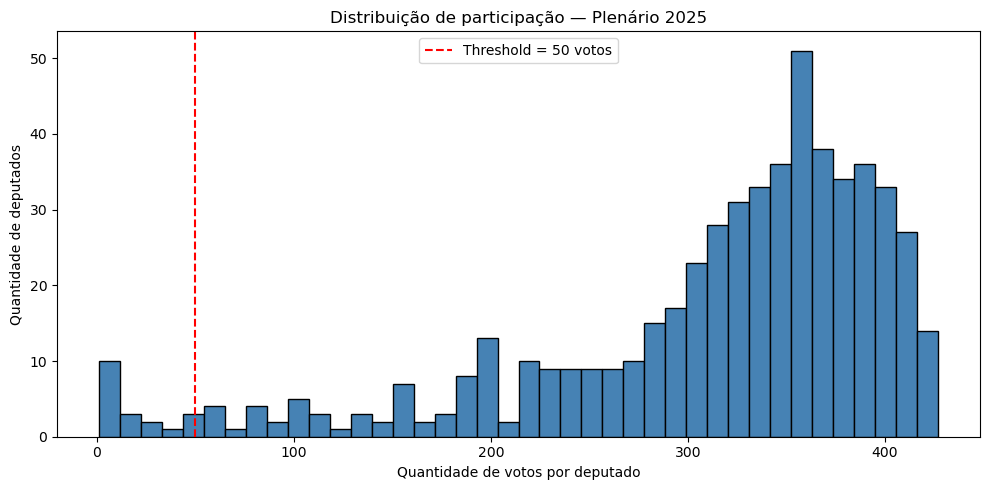

In [5]:
votes_per_deputy = df_votos.groupby('deputado_id').size()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(votes_per_deputy, bins=40, color='steelblue', edgecolor='black')
ax.axvline(50, color='red', linestyle='--', linewidth=1.5, label='Threshold = 50 votos')
ax.set_xlabel('Quantidade de votos por deputado')
ax.set_ylabel('Quantidade de deputados')
ax.set_title('Distribuição de participação — Plenário 2025')
ax.legend()

print(f"Mediana: {votes_per_deputy.median():.0f} votos")
print(f"Média: {votes_per_deputy.mean():.0f} votos")
print(f"Deputados com < 50 votos: {(votes_per_deputy < 50).sum()}")
print(f"Deputados com >= 50 votos: {(votes_per_deputy >= 50).sum()}")

plt.tight_layout()
plt.show()

## 4. Quórum por votação

Quantos deputados votaram em cada votação. O mínimo foi 263 e a mediana 405 — quórum alto em todas as votações. Nenhuma votação com menos de 100 deputados, então não há necessidade de filtrar votações por baixa participação.

Mediana: 405 deputados
Média: 399 deputados
Mínimo: 263 deputados
Máximo: 494 deputados
Votações com < 100 deputados: 0


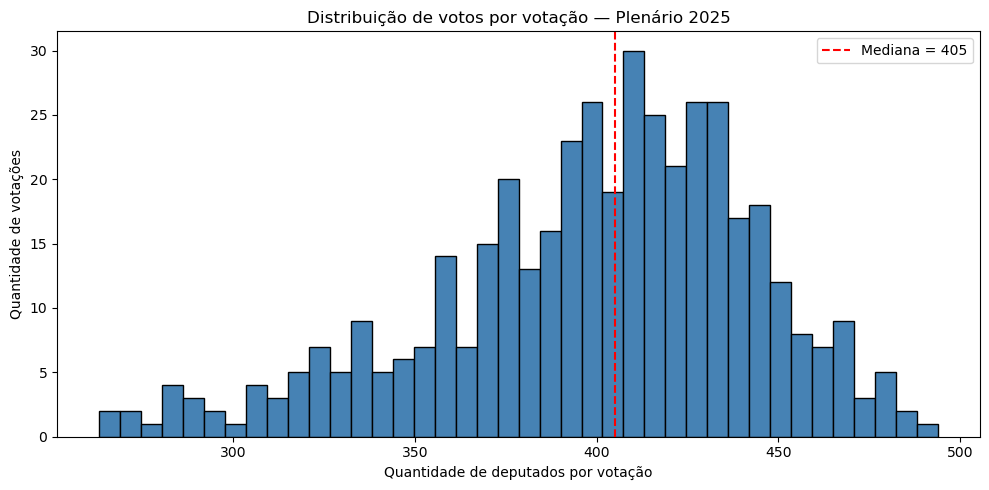

In [6]:
deputados_por_votacao = df_votos.groupby('votacao_id').size()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(deputados_por_votacao, bins=40, color='steelblue', edgecolor='black')
ax.axvline(deputados_por_votacao.median(), color='red', linestyle='--', linewidth=1.5,
           label=f'Mediana = {deputados_por_votacao.median():.0f}')
ax.set_xlabel('Quantidade de deputados por votação')
ax.set_ylabel('Quantidade de votações')
ax.set_title('Distribuição de votos por votação — Plenário 2025')
ax.legend()

print(f"Mediana: {deputados_por_votacao.median():.0f} deputados")
print(f"Média: {deputados_por_votacao.mean():.0f} deputados")
print(f"Mínimo: {deputados_por_votacao.min()} deputados")
print(f"Máximo: {deputados_por_votacao.max()} deputados")
print(f"Votações com < 100 deputados: {(deputados_por_votacao < 100).sum()}")

plt.tight_layout()
plt.show()

## 5. Coesão partidária

**Método:** para cada votação, determina a **maioria do partido** (Sim ou Não, entre os membros que votaram Sim/Não). Depois calcula a taxa de concordância de cada deputado com sua maioria partidária. A coesão do partido é a média dessas taxas individuais (cada deputado conta igualmente, independente de quantas votações participou).

Partidos com menos de 5 deputados são excluídos (coesão trivial).

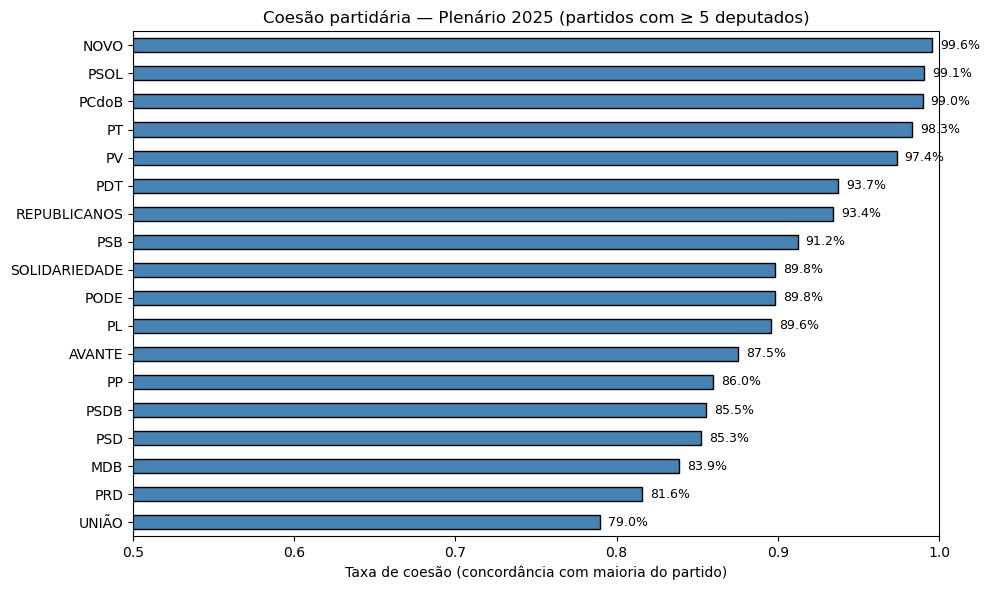

In [ ]:
df_votos_sim_nao = df_votos[df_votos['voto'].isin(['Sim', 'Não'])].copy()
df_votos_sim_nao['voted_sim'] = (df_votos_sim_nao['voto'] == 'Sim')

party_majority = (
    df_votos_sim_nao
    .groupby(['votacao_id', 'deputado_siglaPartido'])['voted_sim']
    .mean()
    .gt(0.5)
    .rename('party_majority_sim')
)

df_votos_sim_nao = df_votos_sim_nao.merge(party_majority, on=['votacao_id', 'deputado_siglaPartido'])
df_votos_sim_nao['agreed'] = df_votos_sim_nao['voted_sim'] == df_votos_sim_nao['party_majority_sim']

deputy_agreement = df_votos_sim_nao.groupby('deputado_id')['agreed'].mean().rename('agreement_rate')

party_sizes = df_votos_sim_nao.groupby('deputado_siglaPartido')['deputado_id'].nunique()
big_parties = party_sizes[party_sizes >= 5].index

party_cohesion = (
    df_votos_sim_nao[df_votos_sim_nao['deputado_siglaPartido'].isin(big_parties)]
    .groupby(['deputado_id', 'deputado_siglaPartido'])['agreed'].mean()
    .groupby('deputado_siglaPartido').mean()
    .sort_values(ascending=False)
    .rename('cohesion')
)

fig, ax = plt.subplots(figsize=(10, 6))
party_cohesion.plot.barh(ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Taxa de coesão (concordância com maioria do partido)')
ax.set_ylabel('')
ax.set_title('Coesão partidária — Plenário 2025 (partidos com ≥ 5 deputados)')
ax.invert_yaxis()
ax.set_xlim(0.5, 1.0)

for i, v in enumerate(party_cohesion):
    ax.text(v + 0.005, i, f'{v:.1%}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 6. Ranking de rebeldes

Deputados que mais divergem da maioria do seu partido, filtrados para no mínimo 50 votos Sim/Não (evita resultados ruidosos de deputados com pouca participação).

Ordenado por **menor taxa de concordância** — os primeiros da lista são os maiores "dissidentes" dentro de seus partidos.

In [53]:
deputy_vote_count = df_votos_sim_nao.groupby('deputado_id').size().rename('n_votes')

rebels = pd.concat([deputy_agreement, deputy_vote_count], axis=1)

rebels = rebels[rebels['n_votes'] >= 50].sort_values(['agreement_rate'])

rebels = rebels.merge(df_deputados, on=["deputado_id"])

rebels_display = (
    rebels
    [['nome', 'deputado_siglaPartido', 'deputado_siglaUf', 'agreement_rate', 'n_votes']]
    .rename(columns={
        'nome': 'Deputado',
        'deputado_siglaPartido': 'Partido',
        'deputado_siglaUf': 'UF',
        'agreement_rate': 'Concordância',
        'n_votes': 'Votos',
    })
    .head(50)
    .style
    .format({'Concordância': '{:.1%}'})
    .background_gradient(subset=['Concordância'], cmap='RdYlGn')
)

rebels_display

,Deputado,Partido,UF,Concordância,Votos
0,João Carlos Bacelar,PL,BA,32.7%,199
1,Sonize Barbosa,PL,AP,34.1%,82
2,Kim Kataguiri,UNIÃO,SP,41.1%,360
3,Mauricio Marcon,PL,RS,41.6%,392
4,Sargento Fahur,PSD,PR,42.4%,425
5,Junior Lourenço,PL,MA,42.8%,283
6,Antonio Carlos Rodrigues,PL,SP,44.1%,390
7,Delegado Palumbo,MDB,SP,44.4%,421
8,Evair Vieira de Melo,PP,ES,44.8%,357
9,Pezenti,MDB,SC,45.7%,407
